# Future Work: Hybrid Kinetic ML for LAI Polymer Drug Release

This notebook preserves the hybrid kinetic ML extension that was moved out of the main paper workflow. It fits Weibull/logistic empirical curves, predicts Weibull kinetic parameters from formulation descriptors, and evaluates reconstructed release curves as future work.


### Notebook setup

Run this cell in Colab or a fresh local environment. If the packages are already installed, the cell does nothing.


In [194]:
import importlib.util
import shutil
import subprocess
import sys

REQUIRED_PACKAGES = {
    "catboost": "catboost",
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "shap": "shap",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "openpyxl": "openpyxl",
    "statsmodels": "statsmodels",
}

missing_packages = [
    package_name
    for import_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    if shutil.which("uv"):
        cmd = ["uv", "pip", "install", "--python", sys.executable, "-q", *missing_packages]
    else:
        cmd = [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    subprocess.check_call(cmd)
else:
    print("All required packages are already installed.")

All required packages are already installed.


### Reproducibility imports and settings

This section defines the reproducible Python environment used for the future-work kinetic analysis.


In [195]:
import os
import warnings
warnings.filterwarnings("ignore")

# Keep Matplotlib cache inside the project when the user home cache is not writable.
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib_cache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "lai_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

### Dataset

Load the release dataset and sort each profile by time.


In [196]:
DATA_PATH = "Dataset_17_feat.csv"

# Colab helper: if the file is not present, ask the user to upload it.
# if not os.path.exists(DATA_PATH):
#     try:
#         from google.colab import files
#         print("Dataset_17_feat.csv not found. Please upload it now.")
#         uploaded = files.upload()
#         if "Dataset_17_feat.csv" in uploaded:
#             DATA_PATH = "Dataset_17_feat.csv"
#     except Exception:
#         pass

df = pd.read_csv(DATA_PATH)

# Sort by profile and time. This is useful for profile plotting later.
df = df.sort_values(["Experimental_index", "Time"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
display(df.head())
display(df.dtypes)

Dataset shape: (3783, 20)


,Experimental_index,DP_Group,LA/GA,Polymer_MW,CL Ratio,Drug_Tm,Drug_Pka,Initial D/M ratio,DLC,SA-V,SE,Drug_Mw,Drug_TPSA,Drug_NHA,Drug_LogP,Time,T=0.25,T=0.5,T=1.0,Release
0,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,0.00,0.04,0.05,0.09,0.00
1,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,0.17,0.04,0.05,0.09,0.03
2,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,1.03,0.04,0.05,0.09,0.12
3,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,3.26,0.04,0.05,0.09,0.20
4,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,7.04,0.04,0.05,0.09,0.28


Experimental_index      int64
DP_Group               object
LA/GA                 float64
Polymer_MW            float64
CL Ratio              float64
Drug_Tm               float64
Drug_Pka              float64
Initial D/M ratio     float64
DLC                   float64
SA-V                  float64
SE                    float64
Drug_Mw               float64
Drug_TPSA             float64
Drug_NHA              float64
Drug_LogP             float64
Time                  float64
T=0.25                float64
T=0.5                 float64
T=1.0                 float64
Release               float64
dtype: object

### Feature sets and grouped validation

The kinetic-parameter prediction uses the same identifiers, feature definitions, and grouped-validation strategy as the main notebook.


In [197]:
ID_COLS = ["Experimental_index", "DP_Group"]
TARGET = "Release"
EARLY_FEATURES = ["T=0.25", "T=0.5", "T=1.0"]

# All numeric input columns except identifiers and target.
ALL_FEATURES = [c for c in df.columns if c not in ID_COLS + [TARGET]]

# Zero-shot: no early measured release values.
ZERO_SHOT_FEATURES = [c for c in ALL_FEATURES if c not in EARLY_FEATURES]

# Few-shot: includes early measured release values.
FEW_SHOT_FEATURES = ALL_FEATURES.copy()

# Main grouping variable for profile-aware validation.
# This prevents rows from the same release profile appearing in both train and test.
MAIN_GROUP_COL = "Experimental_index"
STRICT_GROUP_COL = "DP_Group"
GROUP_COL = MAIN_GROUP_COL
groups = df[GROUP_COL]

# Optional stricter validation. Leave False for the main paper results unless explicitly reporting
# drug-polymer-group generalization as a sensitivity analysis.
RUN_STRICT_DP_GROUP_VALIDATION = False

print("All features:", ALL_FEATURES)
print()
print("Zero-shot features:", ZERO_SHOT_FEATURES)
print()
print("Few-shot features:", FEW_SHOT_FEATURES)
print()
print("Main grouped-validation column:", MAIN_GROUP_COL)
print("Optional stricter grouped-validation column:", STRICT_GROUP_COL)
print("Number of unique release profiles:", df["Experimental_index"].nunique())
print("Number of unique drug-polymer groups:", df["DP_Group"].nunique())


All features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time', 'T=0.25', 'T=0.5', 'T=1.0']

Zero-shot features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time']

Few-shot features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time', 'T=0.25', 'T=0.5', 'T=1.0']

Main grouped-validation column: Experimental_index
Optional stricter grouped-validation column: DP_Group
Number of unique release profiles: 181
Number of unique drug-polymer groups: 34


In [206]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def make_group_splits(X, y, group_values, n_splits=5):
    n_groups = pd.Series(group_values).nunique()
    if n_groups < n_splits:
        raise ValueError(f"Need at least {n_splits} groups for GroupKFold, but found {n_groups}.")
    splitter = GroupKFold(n_splits=n_splits)
    return splitter.split(X, y, group_values)

def evaluate_group_cv(model, X, y, group_values, n_splits=5, group_col=MAIN_GROUP_COL, source_df=None):
    '''
    Evaluates a regression model using GroupKFold.

    The default grouping column is Experimental_index. DP_Group should be used only
    for an optional stricter sensitivity analysis.
    '''
    if source_df is None:
        source_df = df.loc[X.index]

    group_values = pd.Series(group_values, index=X.index)
    fold_rows = []
    oof_pred = np.zeros(len(y), dtype=float)
    oof_fold = np.zeros(len(y), dtype=int)

    for fold, (train_idx, test_idx) in enumerate(make_group_splits(X, y, group_values, n_splits=n_splits)):
        model_fold = clone(model)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model_fold.fit(X_train, y_train)
        pred = np.ravel(model_fold.predict(X_test))

        oof_pred[test_idx] = pred
        oof_fold[test_idx] = fold

        metrics = regression_metrics(y_test, pred)
        metrics["fold"] = fold
        metrics["group_col"] = group_col
        metrics["n_test_rows"] = len(test_idx)
        metrics["n_test_groups"] = group_values.iloc[test_idx].nunique()
        fold_rows.append(metrics)

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "group_col": group_col,
        "MAE_mean": fold_df["MAE"].mean(),
        "MAE_std": fold_df["MAE"].std(),
        "RMSE_mean": fold_df["RMSE"].mean(),
        "RMSE_std": fold_df["RMSE"].std(),
        "R2_mean": fold_df["R2"].mean(),
        "R2_std": fold_df["R2"].std()
    }

    oof_df = pd.DataFrame({
        "y_true": y.values,
        "y_pred": oof_pred,
        "fold": oof_fold,
        "group_col": group_col,
        "Experimental_index": source_df["Experimental_index"].values,
        "DP_Group": source_df["DP_Group"].values,
        "Time": source_df["Time"].values
    })

    return fold_df, summary, oof_df

## Future work: Hybrid kinetic ML with Weibull/logistic curve fitting and parameter prediction

The hybrid approach first fits empirical kinetic curves to each observed release profile. The fitted Weibull parameters (`Fmax`, `tau`, `beta`) are then predicted from formulation descriptors, allowing a full release curve to be reconstructed from predicted kinetic parameters.

In [217]:
def weibull(t, fmax, tau, beta):
    t = np.asarray(t, dtype=float)
    return fmax * (1 - np.exp(-((np.maximum(t, 0) / tau) ** beta)))

def logistic4(t, y0, fmax, k, tmid):
    t = np.asarray(t, dtype=float)
    return y0 + (fmax - y0) / (1 + np.exp(-k * (t - tmid)))

def aic_score(y_true, y_pred, n_params):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    rss = np.sum(residuals ** 2)
    n = len(y_true)
    rss = max(rss, 1e-12)
    return n * np.log(rss / n) + 2 * n_params

def fit_weibull_profile(profile):
    profile = profile.sort_values("Time")
    t = profile["Time"].values.astype(float)
    y_obs = np.clip(profile["Release"].values.astype(float), 0, 1.2)

    if len(np.unique(t)) < 4:
        return None

    t_nonzero = t[t > 0]
    tau_start = np.median(t_nonzero) if len(t_nonzero) > 0 else 1.0

    p0 = [min(1.1, max(y_obs) + 0.05), max(tau_start, 0.1), 1.0]
    bounds = ([0.0, 0.01, 0.05], [1.2, 1000.0, 10.0])

    try:
        popt, _ = curve_fit(
            weibull, t, y_obs, p0=p0, bounds=bounds, maxfev=30000
        )
        y_fit = weibull(t, *popt)
        return {
            "Fmax": popt[0],
            "tau": popt[1],
            "beta": popt[2],
            "weibull_RMSE": np.sqrt(mean_squared_error(y_obs, y_fit)),
            "weibull_AIC": aic_score(y_obs, y_fit, n_params=3)
        }
    except Exception:
        return None

def fit_logistic_profile(profile):
    profile = profile.sort_values("Time")
    t = profile["Time"].values.astype(float)
    y_obs = np.clip(profile["Release"].values.astype(float), 0, 1.2)

    if len(np.unique(t)) < 4:
        return None

    p0 = [max(0.0, min(y_obs)), min(1.1, max(y_obs) + 0.05), 0.1, np.median(t)]
    bounds = ([0.0, 0.0, 0.001, 0.0], [0.6, 1.2, 10.0, 1000.0])

    try:
        popt, _ = curve_fit(
            logistic4, t, y_obs, p0=p0, bounds=bounds, maxfev=30000
        )
        y_fit = logistic4(t, *popt)
        return {
            "log_y0": popt[0],
            "log_Fmax": popt[1],
            "log_k": popt[2],
            "log_tmid": popt[3],
            "logistic_RMSE": np.sqrt(mean_squared_error(y_obs, y_fit)),
            "logistic_AIC": aic_score(y_obs, y_fit, n_params=4)
        }
    except Exception:
        return None

In [218]:
kinetic_rows = []

for profile_id, g in df.groupby("Experimental_index"):
    weib = fit_weibull_profile(g)
    logi = fit_logistic_profile(g)

    row = {
        "Experimental_index": profile_id,
        "DP_Group": g["DP_Group"].iloc[0],
        "n_points": len(g)
    }

    if weib is not None:
        row.update(weib)

    if logi is not None:
        row.update(logi)

    kinetic_rows.append(row)

kinetic_df = pd.DataFrame(kinetic_rows)

# Decide which empirical curve fit was better for each profile, when both are available.
kinetic_df["best_curve_by_AIC"] = np.where(
    kinetic_df["weibull_AIC"] <= kinetic_df["logistic_AIC"],
    "Weibull",
    "Logistic"
)

display(kinetic_df.head())
display(kinetic_df[["weibull_RMSE", "logistic_RMSE", "best_curve_by_AIC"]].describe())
display(kinetic_df["best_curve_by_AIC"].value_counts(dropna=False))

kinetic_df.to_csv(os.path.join(OUTPUT_DIR, "kinetic_curve_fit_parameters.csv"), index=False)

,Experimental_index,DP_Group,n_points,Fmax,tau,beta,weibull_RMSE,weibull_AIC,log_y0,log_Fmax,log_k,log_tmid,logistic_RMSE,logistic_AIC,best_curve_by_AIC
0,1,DEX-PEA,29,0.568925,12.749404,0.618787,0.004433,-308.287201,2.943002e-32,0.519962,0.159328,8.973645,0.034526,-187.230082,Weibull
1,2,GEF-PLGA,18,1.200000,48.617610,0.481211,0.039125,-110.676158,5.310597e-30,0.862870,0.075771,14.349361,0.077661,-83.994639,Weibull
2,3,GEF-PLGA,8,1.030508,0.843538,1.069839,0.042068,-44.695315,5.724353e-20,0.998303,2.953395,0.646045,0.070783,-34.370273,Weibull
3,4,GEF-PLGA,19,1.072381,2.969445,0.811659,0.027058,-131.170996,7.278120e-30,1.045964,0.635324,2.285517,0.068908,-93.649471,Weibull
4,5,GEF-PLGA,17,1.200000,56.991874,1.272517,0.031936,-111.096841,2.633548e-29,1.035068,0.062559,39.488626,0.041698,-100.028491,Weibull


,weibull_RMSE,logistic_RMSE
count,181.000000,181.000000
mean,0.029172,0.049330
std,0.020676,0.021648
min,0.003651,0.003651
25%,0.016091,0.031916
50%,0.022394,0.050938
75%,0.036136,0.062440
max,0.115045,0.109968


best_curve_by_AIC
Weibull     136
Logistic     45
Name: count, dtype: int64

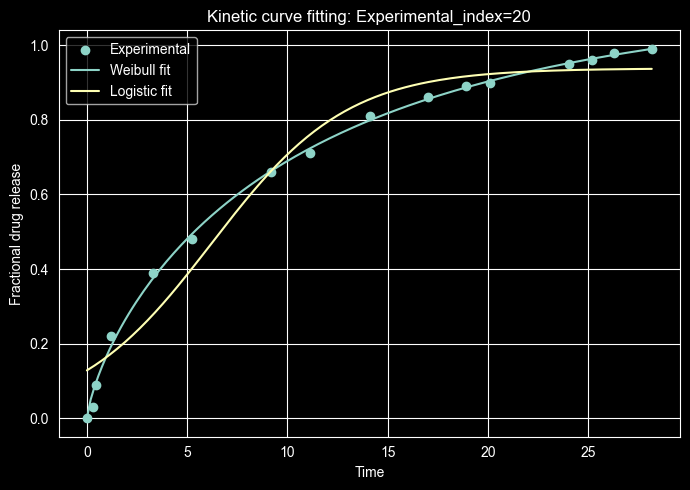

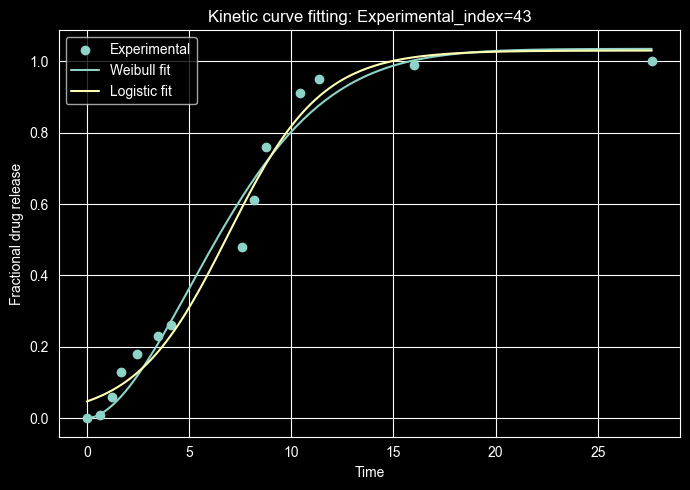

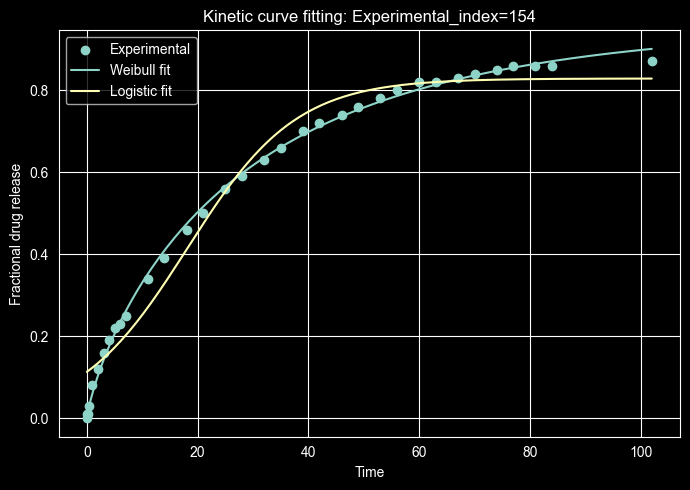

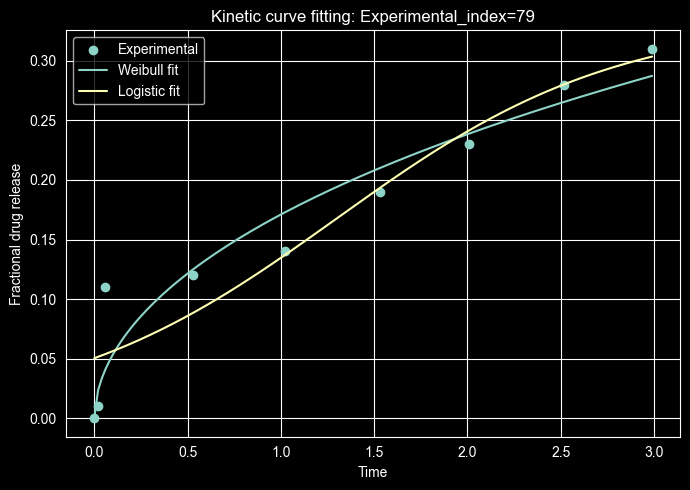

In [219]:
# Visualize fitted Weibull and Logistic curves for a few profiles.
fit_examples = kinetic_df["Experimental_index"].dropna().sample(
    min(4, len(kinetic_df)),
    random_state=RANDOM_STATE
).tolist()

for profile_id in fit_examples:
    profile = df[df["Experimental_index"] == profile_id].sort_values("Time")
    row = kinetic_df[kinetic_df["Experimental_index"] == profile_id].iloc[0]
    t_grid = np.linspace(profile["Time"].min(), profile["Time"].max(), 150)

    plt.figure(figsize=(7, 5))
    plt.scatter(profile["Time"], profile["Release"], label="Experimental")

    if not pd.isna(row.get("Fmax", np.nan)):
        y_weib = weibull(t_grid, row["Fmax"], row["tau"], row["beta"])
        plt.plot(t_grid, y_weib, label="Weibull fit")

    if not pd.isna(row.get("log_Fmax", np.nan)):
        y_log = logistic4(t_grid, row["log_y0"], row["log_Fmax"], row["log_k"], row["log_tmid"])
        plt.plot(t_grid, y_log, label="Logistic fit")

    plt.xlabel("Time")
    plt.ylabel("Fractional drug release")
    plt.title(f"Kinetic curve fitting: Experimental_index={profile_id}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"kinetic_fit_{profile_id}.png"), dpi=300)
    plt.show()

### Paper comment: Kinetic curve fitting

> Each experimental release profile was fitted with empirical kinetic equations. The Weibull model was used as the main curve representation because it can describe different release shapes using only three parameters. Logistic fitting was included as a comparison for sigmoidal profiles. The fitted parameters summarize the entire release curve into interpretable kinetic descriptors.

### Predict Weibull kinetic parameters from formulation descriptors

This section creates one row per release profile and trains a multi-output model to predict `Fmax`, `tau`, and `beta`. The default grouped validation remains `Experimental_index`; optional `DP_Group` validation is available as a stricter sensitivity analysis.

In [220]:
# One row per profile with formulation descriptors.
# We take the first row because formulation descriptors are constant within a profile.
profile_features_df = (
    df.groupby("Experimental_index")
      .first()
      .reset_index()
)

# Features for kinetic parameter prediction.
# Remove Time because the kinetic parameters already describe the whole time profile.
FORMULATION_FEATURES_FEW = [c for c in FEW_SHOT_FEATURES if c != "Time"]
FORMULATION_FEATURES_ZERO = [c for c in ZERO_SHOT_FEATURES if c != "Time"]

profile_param_df = kinetic_df.merge(
    profile_features_df[["Experimental_index", "DP_Group"] + FORMULATION_FEATURES_FEW],
    on=["Experimental_index", "DP_Group"],
    how="left"
)

# Keep only profiles with successful Weibull fit.
profile_param_df = profile_param_df.dropna(subset=["Fmax", "tau", "beta"]).reset_index(drop=True)

display(profile_param_df.head())
print("Number of profiles with successful Weibull fit:", len(profile_param_df))

,Experimental_index,DP_Group,n_points,Fmax,tau,beta,weibull_RMSE,weibull_AIC,log_y0,log_Fmax,log_k,log_tmid,logistic_RMSE,logistic_AIC,best_curve_by_AIC,LA/GA,Polymer_MW,CL Ratio,Drug_Tm,Drug_Pka,Initial D/M ratio,DLC,SA-V,SE,Drug_Mw,Drug_TPSA,Drug_NHA,Drug_LogP,T=0.25,T=0.5,T=1.0
0,1,DEX-PEA,29,0.568925,12.749404,0.618787,0.004433,-308.287201,2.943002e-32,0.519962,0.159328,8.973645,0.034526,-187.230082,Weibull,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.90,0.04,0.05,0.09
1,2,GEF-PLGA,18,1.200000,48.617610,0.481211,0.039125,-110.676158,5.310597e-30,0.862870,0.075771,14.349361,0.077661,-83.994639,Weibull,1.0,44000.0,0.0,213.0,16.11,0.1,0.07,101.69,1.0,446.91,68.74,9.0,4.28,0.05,0.10,0.19
2,3,GEF-PLGA,8,1.030508,0.843538,1.069839,0.042068,-44.695315,5.724353e-20,0.998303,2.953395,0.646045,0.070783,-34.370273,Weibull,1.0,44000.0,0.0,213.0,16.11,0.1,0.03,1200.00,1.0,446.91,68.74,9.0,4.28,0.25,0.45,0.72
3,4,GEF-PLGA,19,1.072381,2.969445,0.811659,0.027058,-131.170996,7.278120e-30,1.045964,0.635324,2.285517,0.068908,-93.649471,Weibull,1.0,44000.0,0.0,213.0,16.11,0.1,0.06,187.50,1.0,446.91,68.74,9.0,4.28,0.11,0.22,0.39
4,5,GEF-PLGA,17,1.200000,56.991874,1.272517,0.031936,-111.096841,2.633548e-29,1.035068,0.062559,39.488626,0.041698,-100.028491,Weibull,1.0,44000.0,0.0,213.0,16.11,0.1,0.08,85.71,1.0,446.91,68.74,9.0,4.28,0.02,0.02,0.03


Number of profiles with successful Weibull fit: 181


In [221]:
def sanitize_weibull_parameter_predictions(param_array, fallback_values):
    '''Replace invalid Weibull parameter predictions and clip to fitting bounds.'''
    arr = np.asarray(param_array, dtype=float)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    fallback = np.asarray(fallback_values, dtype=float)
    if fallback.ndim == 1:
        fallback = fallback.reshape(1, -1)

    arr = np.where(np.isfinite(arr), arr, fallback)
    arr[:, 0] = np.clip(arr[:, 0], 0.0, 1.2)      # Fmax
    arr[:, 1] = np.clip(arr[:, 1], 0.01, 1000.0)  # tau
    arr[:, 2] = np.clip(arr[:, 2], 0.05, 10.0)    # beta
    return arr

def evaluate_parameter_model_cv(profile_df, features, targets, group_col=MAIN_GROUP_COL, n_splits=5):
    '''
    Evaluates ML prediction of kinetic parameters at profile level.
    '''
    Xp = profile_df[features]
    Yp = profile_df[targets]
    group_values = profile_df[group_col]

    pred = np.zeros_like(Yp.values, dtype=float)

    base_model = MultiOutputRegressor(
        LGBMRegressor(
            n_estimators=400,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=5,
            random_state=RANDOM_STATE,
            verbose=-1
        )
    )

    for fold, (train_idx, test_idx) in enumerate(make_group_splits(Xp, Yp, group_values, n_splits=n_splits)):
        model = clone(base_model)
        model.fit(Xp.iloc[train_idx], Yp.iloc[train_idx])
        fold_pred = model.predict(Xp.iloc[test_idx])
        fallback = Yp.iloc[train_idx].median().values
        pred[test_idx, :] = sanitize_weibull_parameter_predictions(fold_pred, fallback)

    rows = []
    for i, target in enumerate(targets):
        rows.append({
            "target": target,
            "group_col": group_col,
            "MAE": mean_absolute_error(Yp.iloc[:, i], pred[:, i]),
            "RMSE": np.sqrt(mean_squared_error(Yp.iloc[:, i], pred[:, i])),
            "R2": r2_score(Yp.iloc[:, i], pred[:, i])
        })

    pred_df = profile_df[["Experimental_index", "DP_Group"]].copy()
    pred_df["group_col"] = group_col
    for i, target in enumerate(targets):
        pred_df[f"{target}_true"] = Yp.iloc[:, i].values
        pred_df[f"{target}_pred"] = pred[:, i]

    return pd.DataFrame(rows), pred_df

PARAM_TARGETS = ["Fmax", "tau", "beta"]

param_results, param_pred_df = evaluate_parameter_model_cv(
    profile_param_df,
    FORMULATION_FEATURES_FEW,
    PARAM_TARGETS,
    group_col=MAIN_GROUP_COL,
    n_splits=5
)

display(param_results)
display(param_pred_df.head())

param_results.to_csv(os.path.join(OUTPUT_DIR, "weibull_parameter_prediction_results.csv"), index=False)
param_pred_df.to_csv(os.path.join(OUTPUT_DIR, "weibull_parameter_oof_predictions.csv"), index=False)

if RUN_STRICT_DP_GROUP_VALIDATION:
    strict_param_results, strict_param_pred_df = evaluate_parameter_model_cv(
        profile_param_df,
        FORMULATION_FEATURES_FEW,
        PARAM_TARGETS,
        group_col=STRICT_GROUP_COL,
        n_splits=5
    )
    display(strict_param_results)
    strict_param_results.to_csv(os.path.join(OUTPUT_DIR, "weibull_parameter_prediction_results_dp_group.csv"), index=False)
    strict_param_pred_df.to_csv(os.path.join(OUTPUT_DIR, "weibull_parameter_oof_predictions_dp_group.csv"), index=False)


,target,group_col,MAE,RMSE,R2
0,Fmax,Experimental_index,0.097618,0.139263,0.540565
1,tau,Experimental_index,35.028715,102.181554,-0.527046
2,beta,Experimental_index,0.396510,0.696546,0.781147


,Experimental_index,DP_Group,group_col,Fmax_true,Fmax_pred,tau_true,tau_pred,beta_true,beta_pred
0,1,DEX-PEA,Experimental_index,0.568925,1.200000,12.749404,96.535288,0.618787,0.799647
1,2,GEF-PLGA,Experimental_index,1.200000,1.200000,48.617610,6.900171,0.481211,0.906459
2,3,GEF-PLGA,Experimental_index,1.030508,1.061590,0.843538,15.317540,1.069839,0.598747
3,4,GEF-PLGA,Experimental_index,1.072381,1.044447,2.969445,15.584143,0.811659,0.660901
4,5,GEF-PLGA,Experimental_index,1.200000,1.166742,56.991874,85.416298,1.272517,0.776742


,target,group_col,MAE,RMSE,R2
0,Fmax,DP_Group,0.167854,0.230807,-0.261977
1,tau,DP_Group,62.571437,121.674450,-1.165239
2,beta,DP_Group,0.558656,0.803262,0.708950


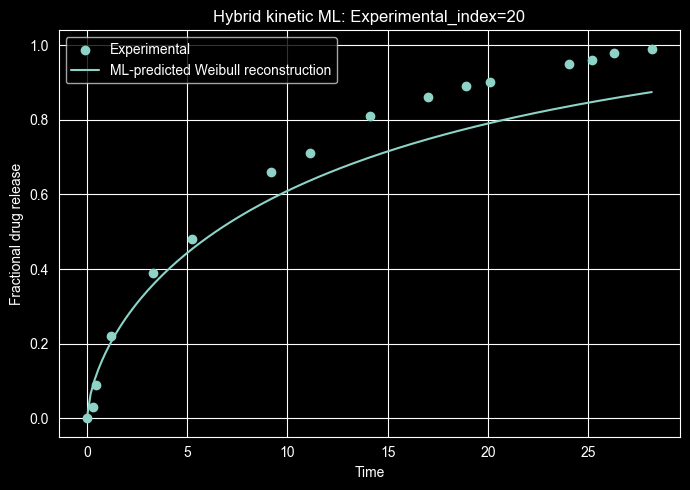

Profile: 20 {'Fmax_pred': np.float64(1.10580030948501), 'tau_pred': np.float64(14.10125381709806), 'beta_pred': np.float64(0.6458111529269468)}


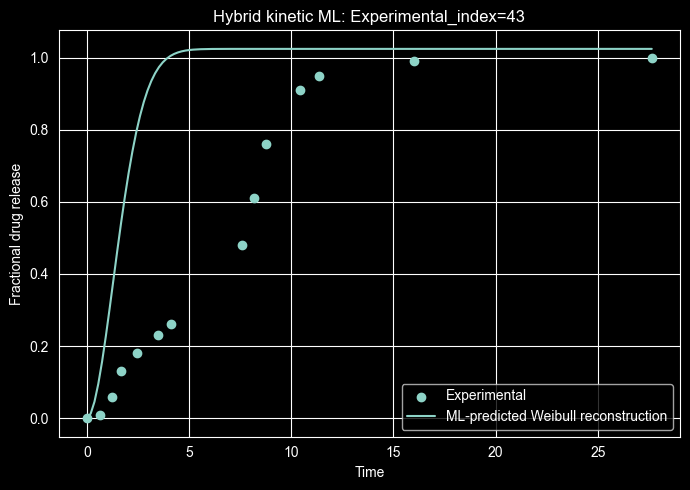

Profile: 43 {'Fmax_pred': np.float64(1.0238955989502465), 'tau_pred': np.float64(1.9492244220609625), 'beta_pred': np.float64(1.8586220053753222)}


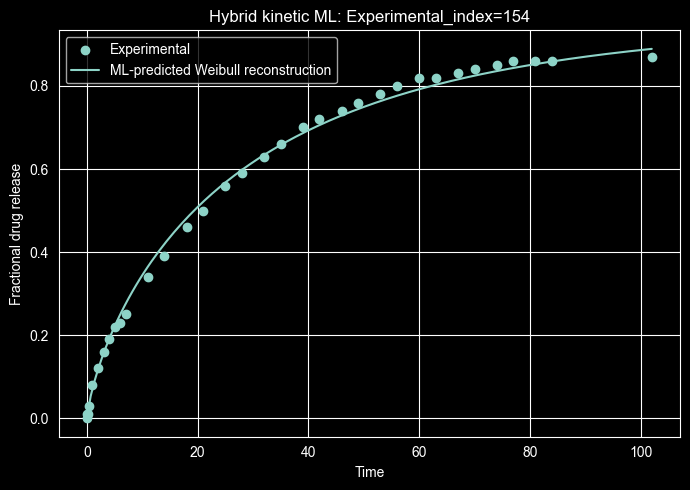

Profile: 154 {'Fmax_pred': np.float64(0.9586968161696282), 'tau_pred': np.float64(28.8516217518485), 'beta_pred': np.float64(0.7638660627029062)}


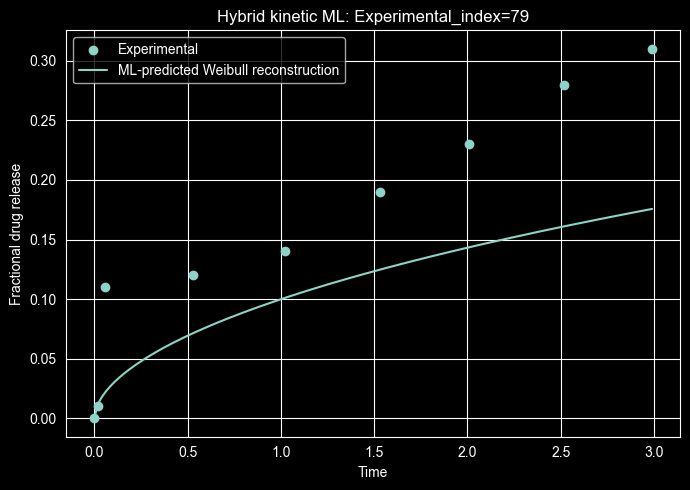

Profile: 79 {'Fmax_pred': np.float64(1.1569904894124152), 'tau_pred': np.float64(79.99148479684274), 'beta_pred': np.float64(0.5487925947672662)}


In [222]:
# Train final parameter model on all profiles for reconstruction examples.
final_param_model = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=400,
        learning_rate=0.03,
        num_leaves=15,
        min_child_samples=5,
        random_state=RANDOM_STATE,
        verbose=-1
    )
)

final_param_model.fit(
    profile_param_df[FORMULATION_FEATURES_FEW],
    profile_param_df[PARAM_TARGETS]
)

def reconstruct_weibull_curve_from_ml(param_model, profile_param_df, profile_id, t_grid):
    row = profile_param_df[profile_param_df["Experimental_index"] == profile_id].iloc[0]
    X_one = pd.DataFrame([row[FORMULATION_FEATURES_FEW].to_dict()])
    fallback = profile_param_df[PARAM_TARGETS].median().values
    fmax, tau, beta = sanitize_weibull_parameter_predictions(param_model.predict(X_one), fallback)[0]
    y_curve = weibull(t_grid, fmax, tau, beta)
    return y_curve, {"Fmax_pred": fmax, "tau_pred": tau, "beta_pred": beta}

# Plot reconstructed hybrid curves.
hybrid_examples = profile_param_df["Experimental_index"].sample(
    min(4, len(profile_param_df)),
    random_state=RANDOM_STATE
).tolist()

for profile_id in hybrid_examples:
    profile = df[df["Experimental_index"] == profile_id].sort_values("Time")
    t_grid = np.linspace(profile["Time"].min(), profile["Time"].max(), 150)

    y_hybrid, pred_params = reconstruct_weibull_curve_from_ml(
        final_param_model,
        profile_param_df,
        profile_id,
        t_grid
    )

    plt.figure(figsize=(7, 5))
    plt.scatter(profile["Time"], profile["Release"], label="Experimental")
    plt.plot(t_grid, y_hybrid, label="ML-predicted Weibull reconstruction")
    plt.xlabel("Time")
    plt.ylabel("Fractional drug release")
    plt.title(f"Hybrid kinetic ML: Experimental_index={profile_id}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"hybrid_weibull_reconstruction_{profile_id}.png"), dpi=300)
    plt.show()

    print("Profile:", profile_id, pred_params)


### Paper-ready hybrid kinetic ML

The hybrid kinetic ML model reduces each release profile to empirical kinetic parameters and then learns the relationship between formulation descriptors and those parameters. This sacrifices some direct point-wise flexibility but improves interpretability because `Fmax`, `tau`, and `beta` describe the asymptotic release, characteristic release time, and curve shape.

### Optional held-out profile evaluation of the hybrid curve model

This cell predicts Weibull parameters in grouped cross-validation, reconstructs each held-out release curve at the original experimental time points, and computes point-wise release metrics. The primary result uses `Experimental_index`; `DP_Group` can be enabled as a stricter validation check.

In [223]:
def hybrid_weibull_group_cv(profile_df, raw_df, features, targets, group_col=MAIN_GROUP_COL, n_splits=5):
    '''
    Cross-validated hybrid model:
    1. Split profiles.
    2. Train ML to predict Weibull parameters.
    3. Predict parameters for held-out profiles.
    4. Reconstruct release at the original experimental time points.
    '''
    Xp = profile_df[features]
    Yp = profile_df[targets]
    group_values = profile_df[group_col]

    all_pred_rows = []

    base_model = MultiOutputRegressor(
        LGBMRegressor(
            n_estimators=400,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=5,
            random_state=RANDOM_STATE,
            verbose=-1
        )
    )

    for fold, (train_idx, test_idx) in enumerate(make_group_splits(Xp, Yp, group_values, n_splits=n_splits)):
        model = clone(base_model)
        train_profiles = profile_df.iloc[train_idx]
        test_profiles = profile_df.iloc[test_idx]

        model.fit(train_profiles[features], train_profiles[targets])

        raw_param_preds = model.predict(test_profiles[features])
        fallback = train_profiles[targets].median().values
        param_preds = sanitize_weibull_parameter_predictions(raw_param_preds, fallback)

        for row_i, (_, profile_row) in enumerate(test_profiles.iterrows()):
            profile_id = profile_row["Experimental_index"]
            fmax, tau, beta = param_preds[row_i]

            raw_profile = raw_df[raw_df["Experimental_index"] == profile_id].copy()
            y_pred = weibull(raw_profile["Time"].values, fmax, tau, beta)

            temp = pd.DataFrame({
                "Experimental_index": profile_id,
                "DP_Group": raw_profile["DP_Group"].values,
                "Time": raw_profile["Time"].values,
                "y_true": raw_profile["Release"].values,
                "y_pred_hybrid": y_pred,
                "fold": fold,
                "group_col": group_col
            })
            all_pred_rows.append(temp)

    pred_df = pd.concat(all_pred_rows, ignore_index=True)
    metrics = regression_metrics(pred_df["y_true"], pred_df["y_pred_hybrid"])
    metrics["group_col"] = group_col
    return metrics, pred_df

hybrid_metrics, hybrid_pred_df = hybrid_weibull_group_cv(
    profile_param_df,
    df,
    FORMULATION_FEATURES_FEW,
    PARAM_TARGETS,
    group_col=MAIN_GROUP_COL,
    n_splits=5
)

display(pd.DataFrame([hybrid_metrics]))
display(hybrid_pred_df.head())

hybrid_pred_df.to_csv(os.path.join(OUTPUT_DIR, "hybrid_weibull_oof_curve_predictions.csv"), index=False)
pd.DataFrame([hybrid_metrics]).to_csv(os.path.join(OUTPUT_DIR, "hybrid_weibull_oof_metrics.csv"), index=False)

if RUN_STRICT_DP_GROUP_VALIDATION:
    strict_hybrid_metrics, strict_hybrid_pred_df = hybrid_weibull_group_cv(
        profile_param_df,
        df,
        FORMULATION_FEATURES_FEW,
        PARAM_TARGETS,
        group_col=STRICT_GROUP_COL,
        n_splits=5
    )
    display(pd.DataFrame([strict_hybrid_metrics]))
    strict_hybrid_pred_df.to_csv(os.path.join(OUTPUT_DIR, "hybrid_weibull_oof_curve_predictions_dp_group.csv"), index=False)
    pd.DataFrame([strict_hybrid_metrics]).to_csv(os.path.join(OUTPUT_DIR, "hybrid_weibull_oof_metrics_dp_group.csv"), index=False)


,MAE,RMSE,R2,group_col
0,0.144068,0.237996,0.475951,Experimental_index


,Experimental_index,DP_Group,Time,y_true,y_pred_hybrid,fold,group_col
0,1,DEX-PEA,0.00,0.00,0.000000,0,Experimental_index
1,1,DEX-PEA,0.17,0.03,0.007506,0,Experimental_index
2,1,DEX-PEA,1.03,0.12,0.031380,0,Experimental_index
3,1,DEX-PEA,3.26,0.20,0.077294,0,Experimental_index
4,1,DEX-PEA,7.04,0.28,0.139126,0,Experimental_index


,MAE,RMSE,R2,group_col
0,0.267434,0.368802,-0.258402,DP_Group


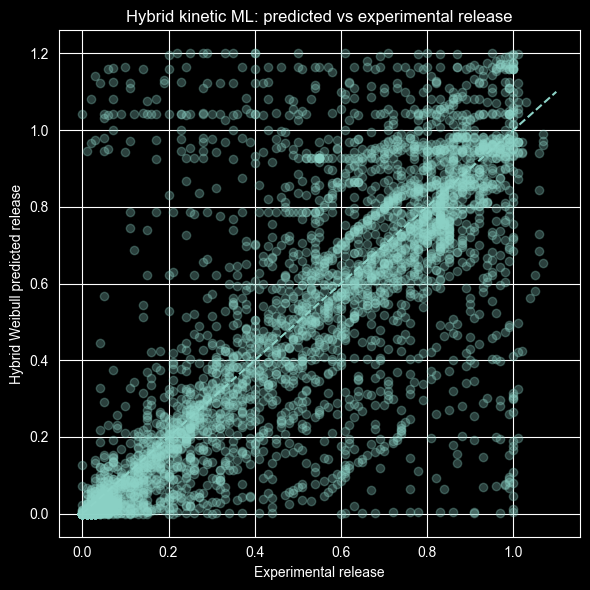

In [224]:
plt.figure(figsize=(6, 6))
plt.scatter(hybrid_pred_df["y_true"], hybrid_pred_df["y_pred_hybrid"], alpha=0.3)
plt.plot([0, 1.1], [0, 1.1], linestyle="--")
plt.xlabel("Experimental release")
plt.ylabel("Hybrid Weibull predicted release")
plt.title("Hybrid kinetic ML: predicted vs experimental release")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hybrid_weibull_predicted_vs_true.png"), dpi=300)
plt.show()

### Paper-ready direct vs hybrid model comparison

The direct model is expected to achieve stronger point-wise accuracy because it predicts each release observation directly. The hybrid model is useful because it converts each profile into kinetic parameters, making the predicted curve easier to discuss in terms of release extent, characteristic time, and curve shape.